In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
insurance=pd.read_csv("D:\\csv files\\insurance.csv")

In [3]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
#Turn all catogories into numbers
df=pd.get_dummies(insurance)
df.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [6]:
X=df.drop("charges",axis=1)
y=df["charges"]
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled[1:10,:]

array([[-1.50996545,  0.5096211 , -0.07876719, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.79795355,  0.38330685,  1.58092576, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [-0.4419476 , -1.30553108, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.51314879, -0.29255641, -0.90861367, -0.98959079,  0.98959079,
         0.5074631 , -0.5074631 , -0.56526686,  1.76548098, -0.61132367,
        -0.56641788],
       [-0.58434998, -0.80765608, -0.90861367,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.56641788],
       [ 0.48366788,  0.45548642, -0.07876719,  1.0105187 , -1.0105187 ,
         0.5074631 , -0.5074631 , -0.56526686, -0.56641788,  1.63579466,
        -0.566

In [29]:
#create train test split function

from sklearn.model_selection import train_test_split
import tensorflow as tf
X_train, X_test, y_train,y_test=train_test_split(X_scaled, y,
                                                 test_size=0.20,
                                                 random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
#apply Deeplearning
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(11),
    tf.keras.layers.Dense(1)
])
insurance_model.compile(loss=tf.keras.losses.mae, 
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])
insurance_model.fit(X_train,y_train,epochs=100)
mae_values=insurance_model.history.history['mae']
len(mae_values)
                        

(1070, 11) (268, 11) (1070,) (268,)
Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13345.6250 - mae: 13345.6250   
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13344.5596 - mae: 13344.5596 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13343.0059 - mae: 13343.0059 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13340.3936 - mae: 13340.3936 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13335.6250 - mae: 13335.6250
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13326.6016 - mae: 13326.6016
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13309.1924 - mae: 13309.1924
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13275.2764 - mae: 13275.2764 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13208.8740 - mae: 13208.8740
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13078.5527 - mae: 13078.5527
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12822.4609 - mae

100

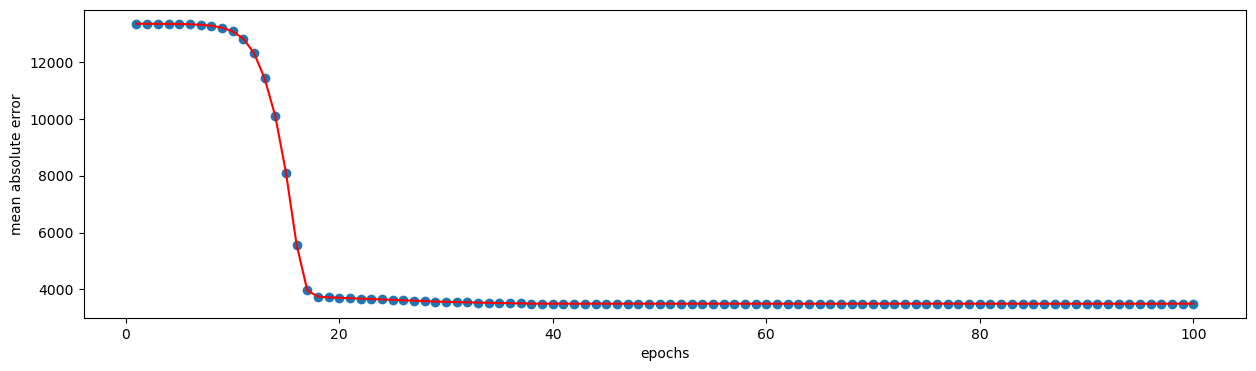

In [30]:
#visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))
plt.scatter(range(1,101), mae_values)
plt.plot(range(1,101),mae_values, color='red')
plt.ylabel("mean absolute error")
plt.xlabel("epochs")
plt.show()

In [22]:
tf.random.set_seed(24)
insurance_model2= tf.keras.Sequential([
    tf.keras.layers.Dense(11),
    tf.keras.layers.Dense(15),
    tf.keras.layers.Dense(1)
])
insurance_model2.compile(loss=tf.keras.losses.mae, 
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])
insurance_model.fit(X_train,y_train,epochs=200)
mae_values=insurance_model2.history.history['mae']
len(mae_values)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3492.0444 - mae: 3492.0444
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3495.1392 - mae: 3495.1392 
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3497.5166 - mae: 3497.5166
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3497.0645 - mae: 3497.0645 
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.3042 - mae: 3496.3042
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3495.0942 - mae: 3495.0942
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.2559 - mae: 3496.2559 
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.0330 - mae: 3496.0330 
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3495.4734 - mae: 3495.4734
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.3411 - mae: 3496.3411 
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3496.7754 - mae: 3496.7754 
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

AttributeError: 'Sequential' object has no attribute 'history'

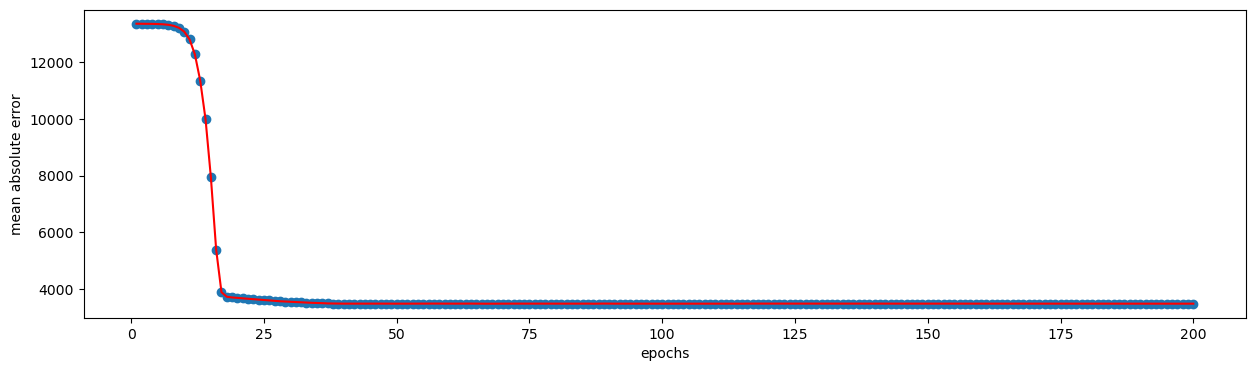

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))
plt.scatter(range(1,201),mae_values)
plt.plot(range(1,201),mae_values, 
         color='red')
plt.ylabel('mean absolute error')
plt.xlabel('epochs')
plt.show()